NON COMPLETO !!!!!!!

# Artist

In [2]:
import numpy as np
from igraph import Graph
from leidenalg import find_partition, ModularityVertexPartition
import numpy as np
import matplotlib.pyplot as plt


edgelist="data/facebook_clean_data/artist_edges.csv"
output="result/facebook/artist_results.txt"
output_robustness= "result/facebook/artist_robustness.txt"
output_degrees = "result/facebook/artist_results_degrees.txt"
save_dir = "images/facebook/artist"

def characterize_network_scalable(
    G,
    outfile=None,
    size_density=1,
    degree_stats=1,
    clustering=1,
    shortest_path=1,
    assortativity=1,
    centralities=1,
    communities=1,
    # parameters to make the function scalable
    max_nodes_for_exact_apl=200_000,
    n_samples_clustering=50_000,
    n_sources_apl=200,
    n_samples_betweenness=1_000,
    max_nodes_for_eigenvector = 100_000,
    max_nodes_for_communities = 2_000_000,
    max_nodes_for_betweenness = 50_000

):
    results = {}

    # ==========================================================
    # 1. Size and density
    # ==========================================================
    if size_density:
        results["N"] = G.vcount()
        results["L"] = G.ecount()
        results["density"] = G.density()

    # ==========================================================
    # 2. Degree distribution
    # ==========================================================
    if degree_stats:
        degrees = np.array(G.degree())
        results["k_avg"] = np.mean(degrees)
        results["k_var"] = np.var(degrees)
        results["degrees"] = degrees

    # ==========================================================
    # 3. Clustering coefficient
    # ==========================================================
    
    

    if clustering:

        print("computing clustering coefficient...", flush=True)

        N = G.vcount()

        n_samples = min(n_samples_clustering, N)

        if n_samples == N:
            print("clustering: exact computation", flush=True)

            clust = G.transitivity_local_undirected(
                vertices=None
            )

        else:
            print(
                f"clustering: sampling {n_samples} nodes out of {N}",
                flush=True
            )

            sample_vertices = np.random.choice(
                N,
                size=n_samples,
                replace=False
            ).tolist()

            clust = G.transitivity_local_undirected(
                vertices=sample_vertices
            )

        # removes nodes without triangles
        clust = np.array(clust)
        clust = clust[~np.isnan(clust)]

        results["clustering"] = (
            float(np.mean(clust))
            if len(clust) > 0
            else np.nan
        )

        results["clustering_sample_size"] = n_samples
        results["clustering_mode"] = (
            "exact" if n_samples == N else "sampled"
        )

        print("clustering DONE", flush=True)

        

    # ==========================================================
    # 4. Average shortest path
    # ==========================================================
    if shortest_path:
        # Giant component
        gcc = G.connected_components().giant()
        Ngcc = gcc.vcount()

        results["gcc_size"] = Ngcc

        if Ngcc <= max_nodes_for_exact_apl:

            print("computing exact average shortest path", flush=True)

            results["avg_shortest_path_on_gcc"] = gcc.average_path_length()
            results["avg_shortest_path_mode"] = "exact"

        else:

            print("computing sampled average shortest path", flush=True)

            # Sample source nodes for BFS estimation
            n_sources = min(n_sources_apl, Ngcc)

            sources = np.random.choice(
                Ngcc,
                size=n_sources,
                replace=False
            ).tolist()

            total_distance = 0
            total_pairs = 0

            for i, s in enumerate(sources, start=1):

                print(
                    f"source {i}/{n_sources} - node {s}",
                    flush=True
                )

                # shortest path distances from source node
                distances = gcc.distances(source=s)[0]

                valid_distances = [
                    d for d in distances
                    if d > 0 and d < float("inf")
                ]

                total_distance += sum(valid_distances)
                total_pairs += len(valid_distances)

            results["avg_shortest_path_on_gcc"] = (
                total_distance / total_pairs
                if total_pairs > 0
                else np.nan
            )

            results["avg_shortest_path_mode"] = "sampled"
            results["avg_shortest_path_n_sources"] = n_sources

    # ==========================================================
    # 5. Assortativity
    # ==========================================================
    if assortativity:
        print("5-assortativity")

        results["assortativity"] = G.assortativity_degree()

    
        
    # ==========================================================
    # 6. Centralities (undirected, scalable)
    # ==========================================================
    if centralities:
        print("6-centralities",flush=True)

        N = G.vcount()
        E = G.ecount()

        # 1. Degree centrality (always exact)
        results["degree_centrality"] = np.asarray(G.degree())

        # 2. Betweenness centrality (exact or not depending on the size of the graph)
        # --------------------------------------------
        # --------------------------------------------
        if N <= max_nodes_for_betweenness:
            print("computing betweenness (exact)...", flush=True)
            bw = G.betweenness(directed=False)
            print("betweenness DONE", flush=True)
            results["betweenness_centrality"] = np.asarray(bw)
            results["betweenness_mode"] = "exact"

        else:
            

            print("computing approximate betweenness...", flush=True)

            N = G.vcount()

            # number of random sources to estimate betweenness
            n_samples = min(n_samples_betweenness, N)

            sources = np.random.choice(
                N,
                size=n_samples,
                replace=False
            ).tolist()

            print(
                f"betweenness: using {n_samples} sampled sources out of {N} nodes",
                flush=True
            )

            # approximate betweenness
            bw = G.betweenness(
                vertices=None,        # all nodes as end points 
                sources=sources,      # only this nodes as sources
                directed=False
            )

            print("betweenness DONE", flush=True)


            
            results["betweenness_centrality"] = np.asarray(bw)

            results["betweenness_sample_size"] = n_samples
            results["betweenness_total_nodes"] = N
            results["betweenness_mode"] = "approximate_sources_sampling"


        
        
        # 3. Eigenvector centrality and PageRank
        # --------------------------------------------
        # Eigenvector centrality calculated only for small graphs
        # --------------------------------------------

        

        N = G.vcount()

        if N <= max_nodes_for_eigenvector:

            print("computing eigenvector centrality...", flush=True)

            eig = G.eigenvector_centrality()

            print("eigenvector DONE", flush=True)

            results["eigenvector_centrality"] = np.asarray(eig)
            results["eigenvector_mode"] = "exact"

        else:

            print(
                f"graph too large ({N} nodes): skipping eigenvector centrality",
                flush=True
            )

            results["eigenvector_mode"] = "skipped"


        # PageRank always calculated
        print("computing PageRank...", flush=True)

        pr = G.pagerank(
            directed=False
        )

        print("PageRank DONE", flush=True)

        results["pagerank"] = np.asarray(pr)



            

    # ==========================================================
    # 7. Communities (Leiden)
    # ==========================================================
    if communities:

        print("computing communities...", flush=True)

        gcc = G.connected_components().giant()

        Ngcc = gcc.vcount()

        results["communities_on_gcc"] = True
        results["gcc_size_for_communities"] = Ngcc

        
        if Ngcc <= max_nodes_for_communities:

            partition = find_partition(
                gcc,
                ModularityVertexPartition
            )

            results["n_communities"] = len(partition)
            results["community_sizes"] = sorted(
                [len(c) for c in partition],
                reverse=True
            )
            results["modularity"] = partition.modularity
            results["community_mode"] = "exact"
            print("communities DONE")

        else:

            print(
                "graph too large: skipping communities",
                flush=True
            )

            results["community_mode"] = "skipped"


    
    # ==========================================================
    # Save results to files
    # ==========================================================

    if outfile is not None:

        
        with open(outfile, "w") as f:

            for key, value in results.items():

                if key == "degrees":
                    continue


                if isinstance(value, dict):

                    f.write(f"{key}\n")

                    for k, v in value.items():
                        f.write(f"    {k}: {v}\n")


                # big data, separate file
                elif isinstance(value, np.ndarray):

                    array_file = outfile.replace(
                        ".txt",
                        f"_{key}.txt"
                    )

                    np.savetxt(
                        array_file,
                        value,
                        fmt="%.10g"
                    )

                    f.write(
                        f"{key}: saved in {array_file}, "
                        f"shape={value.shape}\n"
                    )


                else:

                    f.write(
                        f"{key}: {value}\n"
                    )


        # ======================================================
        # Save degree distribution separately
        # ======================================================

        if degree_stats:

            degrees_outfile = outfile.replace(
                ".txt",
                "_degrees.txt"
            )

            np.savetxt(
                degrees_outfile,
                degrees,
                fmt="%d"
            )


    

    return results

In [2]:
# Build the graph reading from a file.csv, call the characterizing function
import pandas as pd
import numpy as np
import igraph as ig

# 1. load from file
edges = pd.read_csv(
    edgelist,
    sep=",",
    header=None,
    skiprows=1,
    usecols=[0, 1],
    names=["src", "dst"]
)

# 2. remove self-loops
edges = edges[edges["src"] != edges["dst"]]
print("2-done", flush=True)

# 3. convert in numpy(much faster)
arr = edges[["src", "dst"]].to_numpy()

# 4. order couples (directed → undirected)
arr.sort(axis=1)
print("3-done", flush=True)

# 5. remove duplicates
arr_unique = pd.DataFrame(arr).drop_duplicates().to_numpy()
print("4-done", flush=True)

# 6. create graph igraph
edge_list = list(map(tuple, arr_unique))
G = ig.Graph.TupleList(edge_list, directed=False)
print("5-done", flush=True)

2-done
3-done
4-done
5-done


In [ ]:
res = characterize_network_scalable(G,output)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# INPUT / OUTPUT
# ==========================================================
outfile = output

base = outfile.replace(".txt", "")


os.makedirs(save_dir, exist_ok=True)

# ==========================================================
# LOAD CENTRALITIES
# ==========================================================
deg = np.loadtxt(f"{base}_degree_centrality.txt")
bet = np.loadtxt(f"{base}_betweenness_centrality.txt")
pr  = np.loadtxt(f"{base}_pagerank.txt")

eig_file = f"{base}_eigenvector_centrality.txt"
has_eigen = os.path.exists(eig_file)

if has_eigen:
    eig = np.loadtxt(eig_file)

# ==========================================================
# NORMALIZATION
# ==========================================================
if deg.max() > 0:
    deg = deg / deg.max()

if bet.max() > 0:
    bet = bet / bet.max()

if pr.max() > 0:
    pr = pr / pr.max()

if has_eigen and eig.max() > 0:
    eig = eig / eig.max()



# ==========================================================
# SORT USING DEGREE CENTRALITY
# ==========================================================
order = np.argsort(deg)

deg_sorted = deg[order]
bet_sorted = bet[order]
pr_sorted  = pr[order]

if has_eigen:
    eig_sorted = eig[order]

# ==========================================================
# DEGREE CENTRALITY
# ==========================================================
plt.figure(figsize=(12, 6))
plt.scatter(range(len(deg_sorted)), deg_sorted,
            color="red", s=10, alpha=0.6)

plt.title("Degree Centrality (sorted)")
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Degree centrality (normalized)")
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(
#     f"{save_dir}/degree_centrality_sorted.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

plt.show()

# ==========================================================
# EIGENVECTOR CENTRALITY
# ==========================================================
if has_eigen:

    plt.figure(figsize=(12, 6))

    plt.scatter(
        range(len(eig_sorted)),
        eig_sorted,
        color="blue",
        s=10,
        alpha=0.6
    )

    plt.title("Eigenvector Centrality (sorted)")
    plt.xlabel("Nodes sorted by degree centrality")
    plt.ylabel("Centrality (normalized)")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # plt.savefig(
    #     f"{save_dir}/eigenvector_centrality_sorted.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    # plt.close()

    plt.show()

# ==========================================================
# PAGERANK
# ==========================================================
plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(pr_sorted)),
    pr_sorted,
    color="blue",
    s=10,
    alpha=0.6
)

plt.title("PageRank (sorted)")
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Centrality (normalized)")
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(
#     f"{save_dir}/pagerank_sorted.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

plt.show()

# ==========================================================
# BETWEENNESS CENTRALITY
# ==========================================================
plt.figure(figsize=(12, 6))

plt.scatter(
    range(len(bet_sorted)),
    bet_sorted,
    color="green",
    s=10,
    alpha=0.6
)

plt.title("Betweenness Centrality (sorted)")
plt.xlabel("Nodes sorted by degree centrality")
plt.ylabel("Betweenness centrality (normalized)")
plt.grid(alpha=0.3)
plt.tight_layout()

# plt.savefig(
#     f"{save_dir}/betweenness_centrality_sorted.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# ==========================================================
# DEGREE DISTRIBUTION + CCDF
# ==========================================================
degrees = np.loadtxt(
    f"{base}_degrees.txt",
    dtype=int
)

N = len(degrees)

k_values, counts = np.unique(
    degrees,
    return_counts=True
)

Pk = counts / N

degrees_sorted = np.sort(degrees)

ccdf = (
    N
    - np.searchsorted(
        degrees_sorted,
        k_values,
        side="left"
    )
) / N

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Degree distribution
ax[0].scatter(
    k_values,
    Pk,
    marker="o",
    facecolors="none",
    edgecolors="blue"
)

ax[0].set_xlabel(r"$k$")
ax[0].set_ylabel(r"$P(k)$")
ax[0].set_title("Degree Distribution")
ax[0].grid(True, alpha=0.3)

# CCDF
ax[1].plot(
    k_values,
    ccdf,
    color="red",
    linewidth=1.5
)

ax[1].set_xlabel(r"$k$")
ax[1].set_ylabel(r"$P(K \geq k)$")
ax[1].set_title("Cumulative Degree Distribution (CCDF)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{save_dir}/degree_distribution_and_ccdf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"All figures saved in: {save_dir}")

All figures saved in: images/facebook/artist


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


os.makedirs(save_dir, exist_ok=True)

# ==========================================================
# LOAD CENTRALITIES
# ==========================================================
deg_c = np.loadtxt(
    f"{base}_degree_centrality.txt"
)

bet_c = np.loadtxt(
    f"{base}_betweenness_centrality.txt"
)

pgr_c = np.loadtxt(
    f"{base}_pagerank.txt"
)

eig_file = f"{base}_eigenvector_centrality.txt"
has_eigen = os.path.exists(eig_file)

if has_eigen:
    eig_c = np.loadtxt(eig_file)

# ==========================================================
# CCDF FUNCTION
# ==========================================================
def save_ccdf(values, title, filename):

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    values = np.sort(values)

    n = len(values)

    ccdf = 1.0 - np.arange(1, n + 1) / n

    mask = (values > 0) & (ccdf > 0)

    plt.figure(figsize=(5, 4))

    plt.loglog(
        values[mask],
        ccdf[mask],
        "."
    )

    plt.xlabel(title)
    plt.ylabel("CCDF")
    plt.title(title)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        os.path.join(save_dir, filename),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ==========================================================
# CCDF PLOTS
# ==========================================================
save_ccdf(
    deg_c,
    "Degree Centrality",
    "ccdf_degree_centrality.png"
)

save_ccdf(
    bet_c,
    "Betweenness Centrality",
    "ccdf_betweenness_centrality.png"
)

if has_eigen:
    save_ccdf(
        eig_c,
        "Eigenvector Centrality",
        "ccdf_eigenvector_centrality.png"
    )

save_ccdf(
    pgr_c,
    "PageRank",
    "ccdf_pagerank.png"
)

# ==========================================================
# CORRELATION MATRIX
# ==========================================================
corr_data = {
    "Degree": deg_c,
    "Betweenness": bet_c,
    "PageRank": pgr_c
}

if has_eigen:
    corr_data["Eigenvector"] = eig_c

data = pd.DataFrame(corr_data)

corr = data.corr(method="spearman")

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Spearman Correlation Between Centralities"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        save_dir,
        "centrality_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# ==========================================================
# BETWEENESS VS DEGREE
# ==========================================================
mask = (deg_c > 0) & (bet_c > 0)

plt.figure(figsize=(6, 5))

plt.scatter(
    deg_c[mask],
    bet_c[mask],
    alpha=0.5,
    s=15
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree")
plt.ylabel("Betweenness")

plt.title("Betweenness vs Degree")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        save_dir,
        "betweenness_vs_degree.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# # ==========================================================
# # EIGENVECTOR VS DEGREE
# # ==========================================================
# if has_eigen:

#     mask = (deg_c > 0) & (eig_c > 0)

#     plt.figure(figsize=(6, 5))

#     plt.scatter(
#         deg_c[mask],
#         eig_c[mask],
#         alpha=0.5,
#         s=15
#     )

#     plt.xscale("log")
#     plt.yscale("log")

#     plt.xlabel("Degree")
#     plt.ylabel("Eigenvector Centrality")

#     plt.title(
#         "Eigenvector Centrality vs Degree"
#     )

#     plt.grid(alpha=0.3)

#     plt.tight_layout()

#     plt.savefig(
#         os.path.join(
#             save_dir,
#             "eigenvector_vs_degree.png"
#         ),
#         dpi=300,
#         bbox_inches="tight"
#     )

#     plt.close()

# # ==========================================================
# # PAGERANK VS DEGREE
# # ==========================================================
# mask = (deg_c > 0) & (pgr_c > 0)

# plt.figure(figsize=(6, 5))

# plt.scatter(
#     deg_c[mask],
#     pgr_c[mask],
#     alpha=0.5,
#     s=15
# )

# plt.xscale("log")
# plt.yscale("log")

# plt.xlabel("Degree")
# plt.ylabel("PageRank")

# plt.title("PageRank vs Degree")

# plt.grid(alpha=0.3)

# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         save_dir,
#         "pagerank_vs_degree.png"
#     ),
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

# # ==========================================================
# # PAGERANK VS BETWEENNESS
# # ==========================================================
# mask = (pgr_c > 0) & (bet_c > 0)

# plt.figure(figsize=(6, 5))

# plt.scatter(
#     bet_c[mask],
#     pgr_c[mask],
#     alpha=0.5,
#     s=15
# )

# plt.xscale("log")
# plt.yscale("log")

# plt.xlabel("Betweenness")
# plt.ylabel("PageRank")

# plt.title("PageRank vs Betweenness")

# plt.grid(alpha=0.3)

# plt.tight_layout()

# plt.savefig(
#     os.path.join(
#         save_dir,
#         "pagerank_vs_betweenness.png"
#     ),
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.close()

print(f"All figures saved in: {save_dir}")

# ATTACK

In [ ]:
import igraph as ig
import numpy as np
import random


def s_avg(comp_sizes):
    if len(comp_sizes) <= 1:
        return 0

    comp_sizes = list(comp_sizes)
    comp_sizes.remove(max(comp_sizes))

    return np.mean(comp_sizes) if comp_sizes else 0


def compute_metrics(G, compute_comm=True):

    if G.vcount() == 0:
        return {
            "S": 0,
            "s": 0,
            "C_global": 0,
            "C_local": 0,
            "n_comm": 0,
            "modularity": 0,
            "largest_comm": 0
        }

    # Connected components
    comp = G.components()
    comp_sizes = comp.sizes()

    S = max(comp_sizes) / G.vcount()
    s = s_avg(comp_sizes)

    # Clustering
    try:
        C_global = G.transitivity_undirected()
    except:
        C_global = 0

    try:
        C_local = G.transitivity_avglocal_undirected(mode="zero")
    except:
        C_local = 0

    # Community statistics
    if compute_comm and G.ecount() > 0:

        try:
            part = G.community_leiden(
                objective_function="modularity"
            )

            n_comm = len(part)
            modularity = part.modularity
            largest_comm = max(part.sizes())

        except Exception:

            n_comm = 0
            modularity = 0
            largest_comm = 0

    else:

        n_comm = np.nan
        modularity = np.nan
        largest_comm = np.nan

    return {
        "S": S,
        "s": s,
        "C_global": C_global,
        "C_local": C_local,
        "n_comm": n_comm,
        "modularity": modularity,
        "largest_comm": largest_comm
    }


def robustness_analysis(
        G,
        outfile=None,
        dq=0.005,
        seed=None,
        comm_every=1):

    if seed is not None:
        random.seed(seed)

    N = G.vcount()

    G_rand = G.copy()
    G_att = G.copy()

    rem_step = max(1, int(dq * N))

    f = []

    # Random attack
    S_rand = []
    s_rand = []
    Cg_rand = []
    Cl_rand = []
    Nc_rand = []
    Q_rand = []
    Lc_rand = []

    # Degree attack
    S_att = []
    s_att = []
    Cg_att = []
    Cl_att = []
    Nc_att = []
    Q_att = []
    Lc_att = []

    for step, q in enumerate(np.arange(0, 1, dq)):

        print(f"{q:.3f}")

        f.append(q)

        # ==================================================
        # RANDOM REMOVAL
        # ==================================================

        if G_rand.vcount() > 0:

            nodes = random.sample(
                range(G_rand.vcount()),
                min(rem_step, G_rand.vcount())
            )

            G_rand.delete_vertices(nodes)

        m_rand = compute_metrics(
            G_rand,
            compute_comm=(step % comm_every == 0)
        )

        S_rand.append(m_rand["S"])
        s_rand.append(m_rand["s"])
        Cg_rand.append(m_rand["C_global"])
        Cl_rand.append(m_rand["C_local"])
        Nc_rand.append(m_rand["n_comm"])
        Q_rand.append(m_rand["modularity"])
        Lc_rand.append(m_rand["largest_comm"])

        # ==================================================
        # ADAPTIVE DEGREE ATTACK
        # ==================================================

        if G_att.vcount() > 0:

            deg = np.array(G_att.degree())

            ordered = np.argsort(deg)[::-1]

            to_remove = ordered[
                :min(rem_step, len(ordered))
            ]

            G_att.delete_vertices(to_remove)

        m_att = compute_metrics(
            G_att,
            compute_comm=(step % comm_every == 0)
        )

        S_att.append(m_att["S"])
        s_att.append(m_att["s"])
        Cg_att.append(m_att["C_global"])
        Cl_att.append(m_att["C_local"])
        Nc_att.append(m_att["n_comm"])
        Q_att.append(m_att["modularity"])
        Lc_att.append(m_att["largest_comm"])

    results = {
        "f": np.array(f),

        "S_rand": np.array(S_rand),
        "s_rand": np.array(s_rand),
        "Cg_rand": np.array(Cg_rand),
        "Cl_rand": np.array(Cl_rand),
        "Nc_rand": np.array(Nc_rand),
        "Q_rand": np.array(Q_rand),
        "Lc_rand": np.array(Lc_rand),

        "S_att": np.array(S_att),
        "s_att": np.array(s_att),
        "Cg_att": np.array(Cg_att),
        "Cl_att": np.array(Cl_att),
        "Nc_att": np.array(Nc_att),
        "Q_att": np.array(Q_att),
        "Lc_att": np.array(Lc_att)
    }

    if outfile is not None:

        data = np.column_stack([
            f,

            S_rand,
            s_rand,
            Cg_rand,
            Cl_rand,
            Nc_rand,
            Q_rand,
            Lc_rand,

            S_att,
            s_att,
            Cg_att,
            Cl_att,
            Nc_att,
            Q_att,
            Lc_att
        ])

        header = (
            "f "
            "S_rand s_rand Cg_rand Cl_rand Nc_rand Q_rand Lc_rand "
            "S_att s_att Cg_att Cl_att Nc_att Q_att Lc_att"
        )

        np.savetxt(
            outfile,
            data,
            fmt="%.6f",
            header=header,
            comments=""
        )

    return results






In [ ]:
#############################################
##### Application of robustness_analysis#####
#############################################


######## ATTACK #########

robustness = robustness_analysis(
    G,
    outfile=output_robustness,
    dq=0.005,
    seed=42,
    comm_every=5
)



In [3]:
data = np.loadtxt(
    output_robustness,
    skiprows=1
)

f = data[:, 0]

# Random attack
S_rand  = data[:, 1]
s_rand  = data[:, 2]
Cg_rand = data[:, 3]
Cl_rand = data[:, 4]
Nc_rand = data[:, 5]
Q_rand  = data[:, 6]
Lc_rand = data[:, 7]

# Targeted attack
S_att   = data[:, 8]
s_att   = data[:, 9]
Cg_att  = data[:,10]
Cl_att  = data[:,11]
Nc_att  = data[:,12]
Q_att   = data[:,13]
Lc_att  = data[:,14]

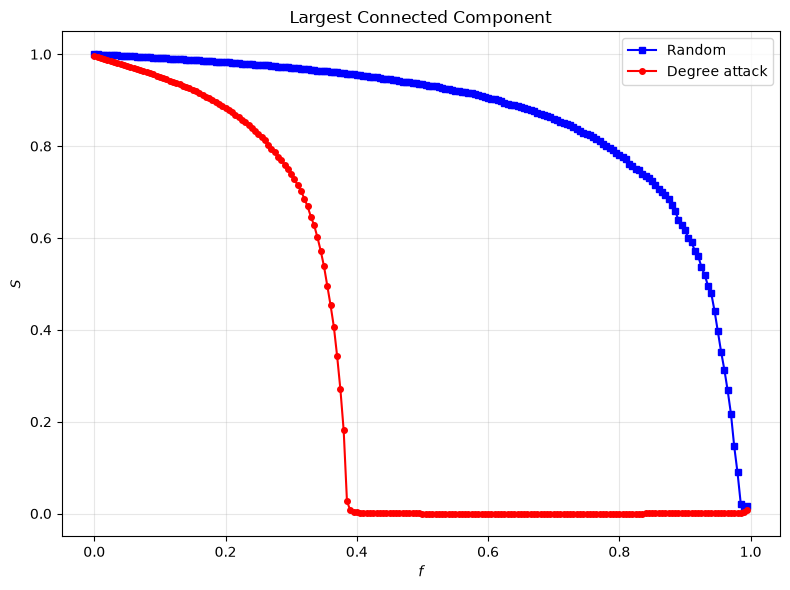

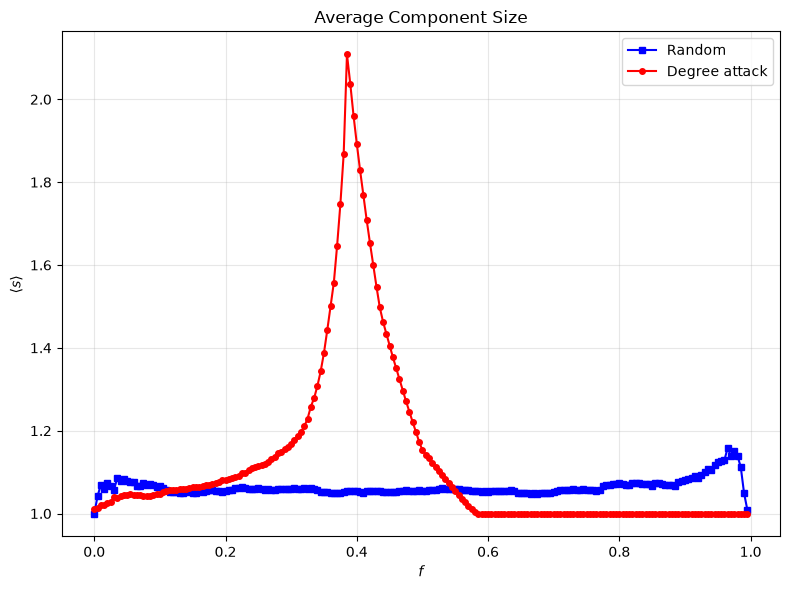

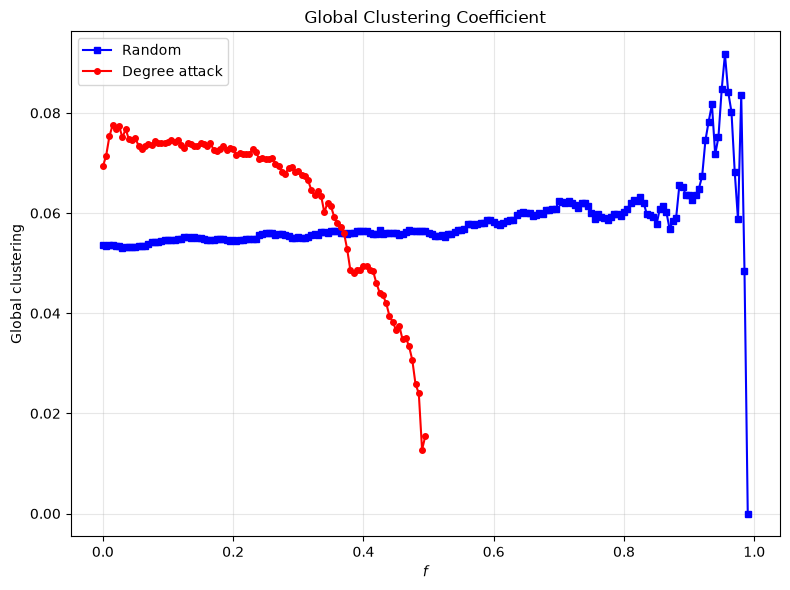

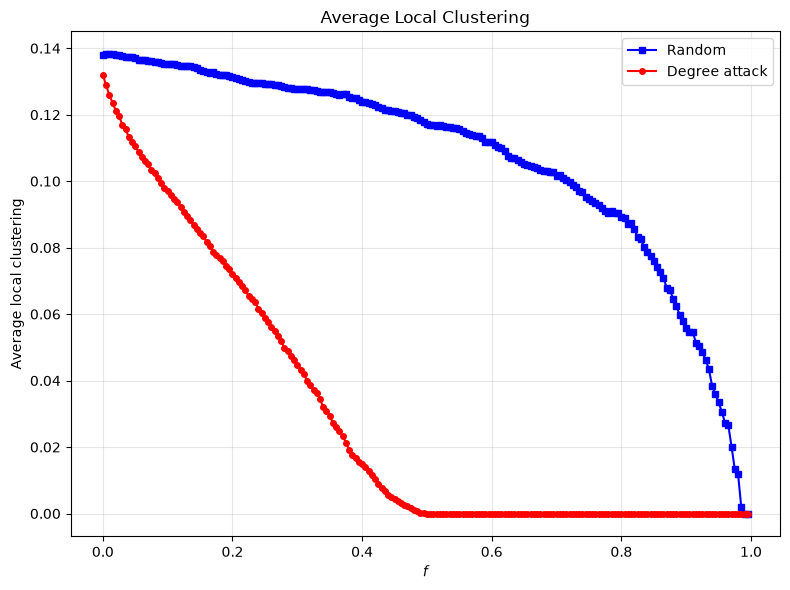

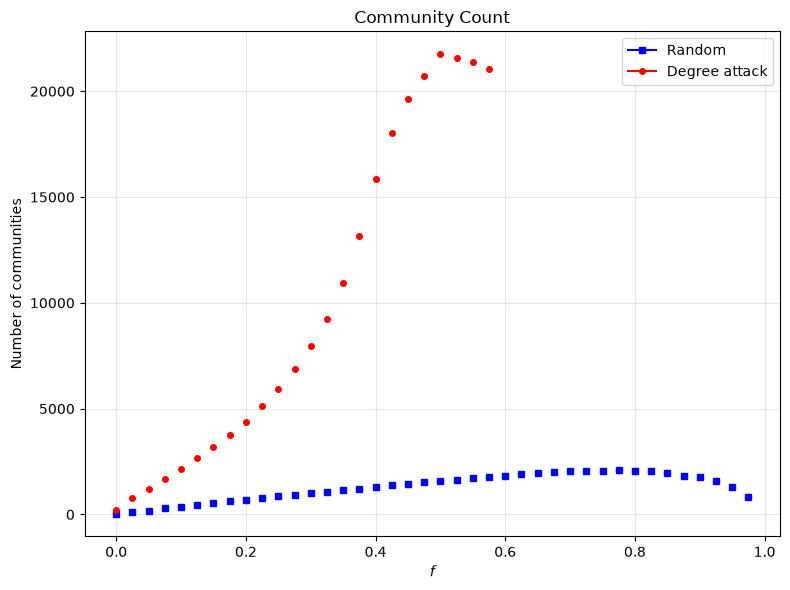

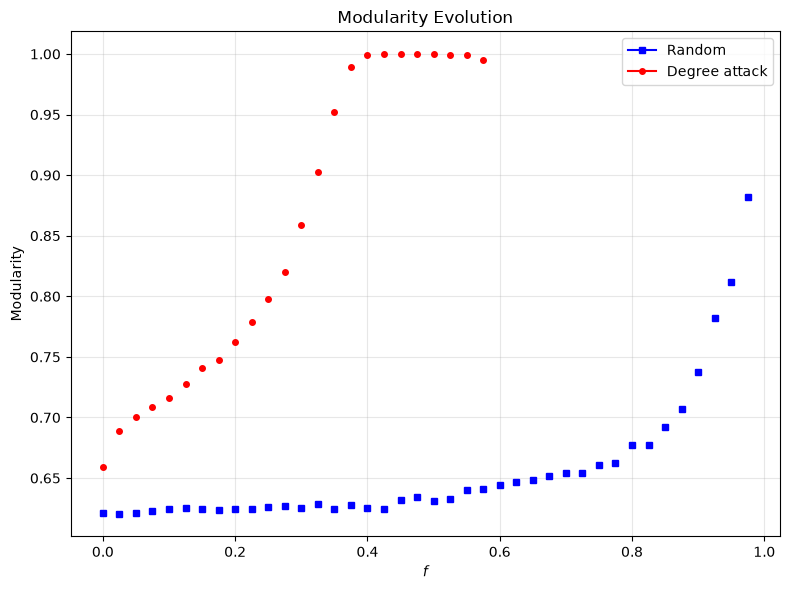

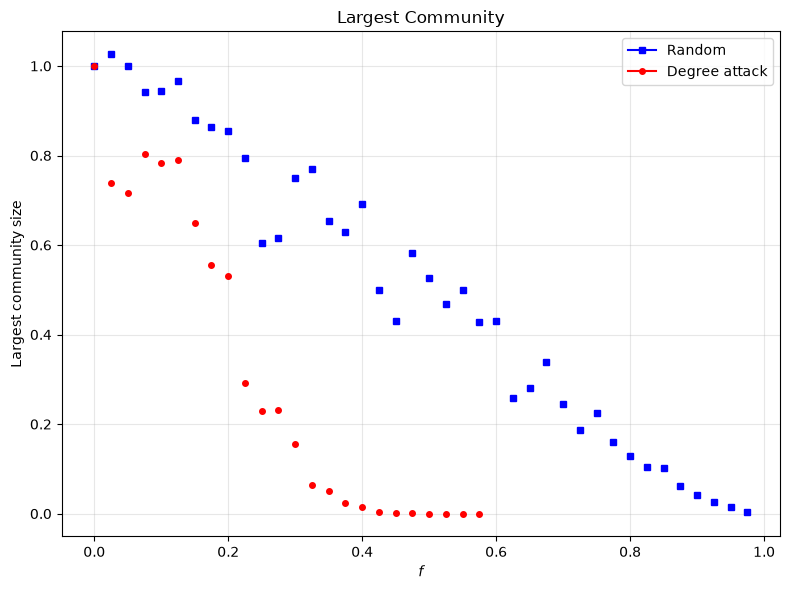

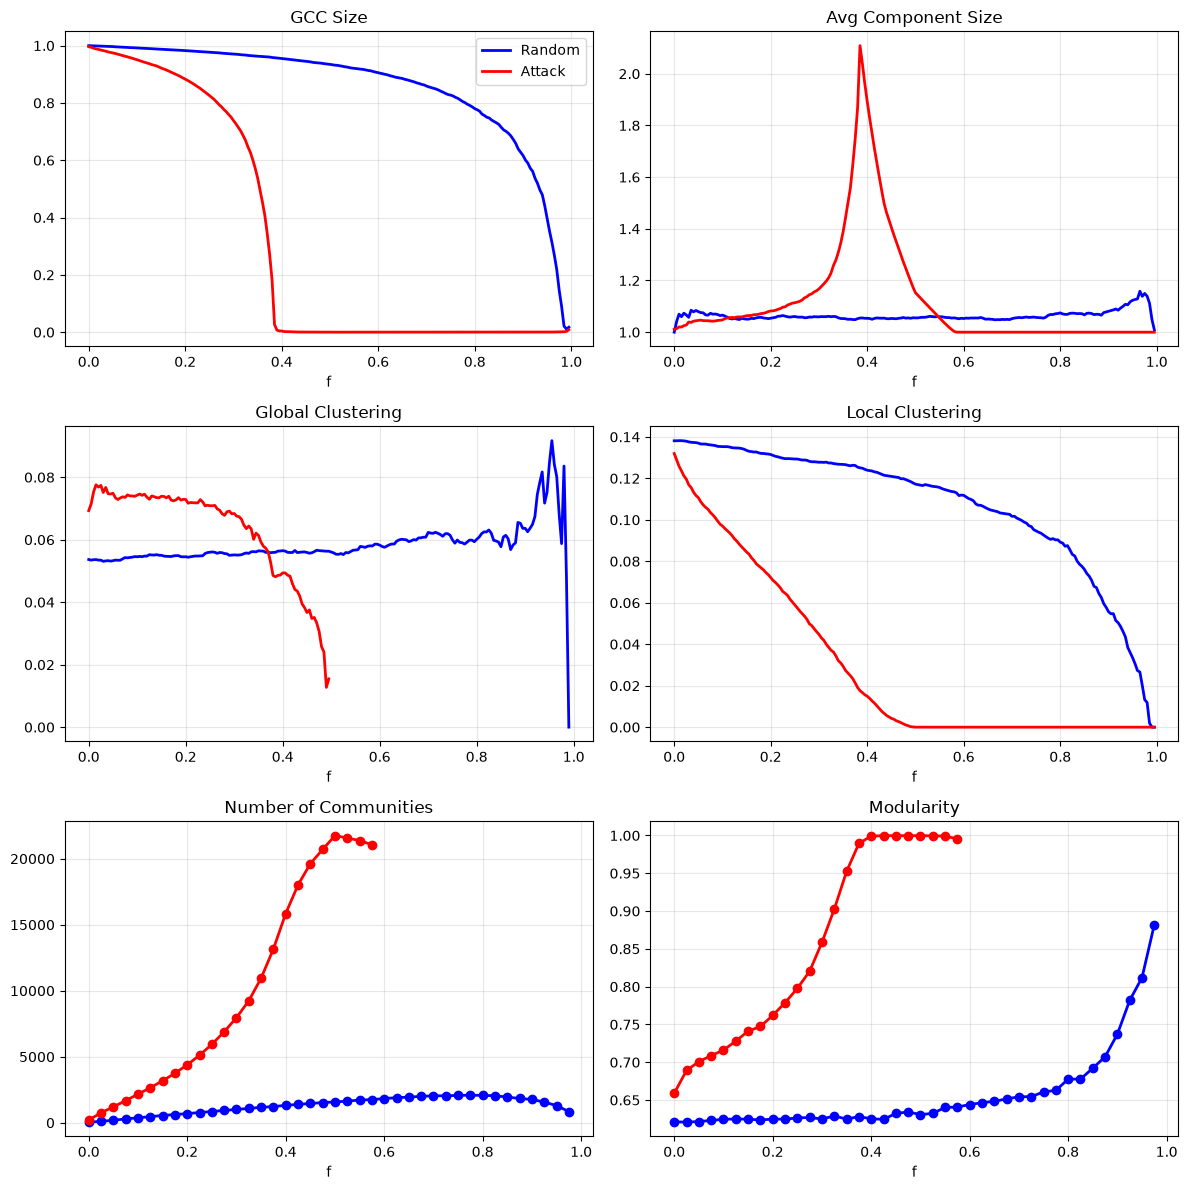

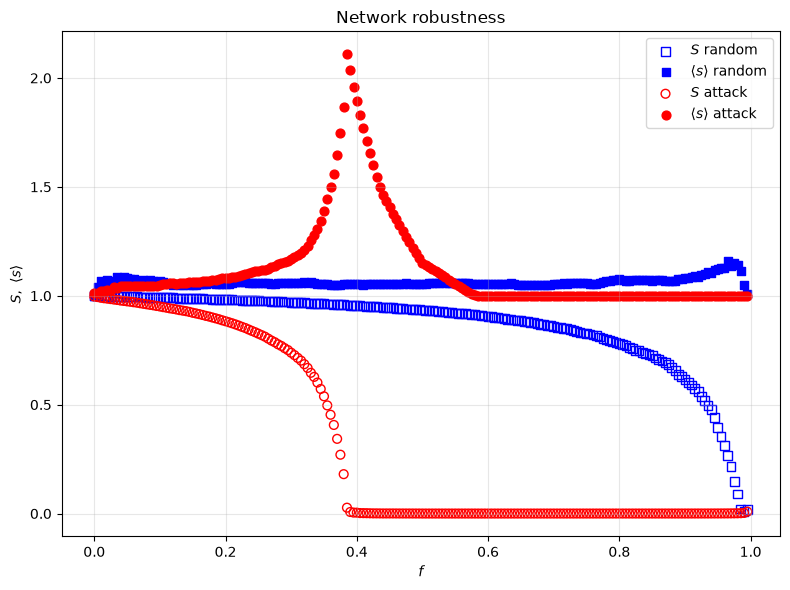

In [27]:
save_summary = True
save_article = True

def plot_metric(
    f,
    rand,
    att,
    ylabel,
    title,
    save=False,
    filename=None
):

    plt.figure(figsize=(8,6))

    plt.plot(
        f, rand,
        'bs-',
        markersize=4,
        label='Random'
    )

    plt.plot(
        f, att,
        'ro-',
        markersize=4,
        label='Degree attack'
    )

    plt.xlabel(r'$f$')
    plt.ylabel(ylabel)
    plt.title(title)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    if save and filename is not None:
        plt.savefig(
            filename,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


# GCC size vs f
plot_metric(
    f,
    S_rand,
    S_att,
    r'$S$',
    'Largest Connected Component',
    save=False,
    filename=f"{save_dir}/gcc_size_vs_fraction_removed.png"
)

# <s> vs f
plot_metric(
    f,
    s_rand,
    s_att,
    r'$\langle s \rangle$',
    'Average Component Size',
    save=False,
    filename=f"{save_dir}/average_component_size_vs_fraction_removed.png"
)


# Clustering vs f
plot_metric(
    f,
    Cg_rand,
    Cg_att,
    'Global clustering',
    'Global Clustering Coefficient',
    save=False,
    filename=f"{save_dir}/global_clustering_vs_fraction_removed.png"
)

# avg loc clustering vs f
plot_metric(
    f,
    Cl_rand,
    Cl_att,
    'Average local clustering',
    'Average Local Clustering',
    save=False,
    filename=f"{save_dir}/local_clustering_vs_fraction_removed.png"
)


# num communties vs f
plot_metric(
    f,
    Nc_rand,
    Nc_att,
    'Number of communities',
    'Community Count',
    save=False,
    filename=f"{save_dir}/community_count_vs_fraction_removed.png"
)


# modularity vs f
plot_metric(
    f,
    Q_rand,
    Q_att,
    'Modularity',
    'Modularity Evolution',
    save=False,
    filename=f"{save_dir}/global_clustering_vs_fraction_removed.png"
)


# normalized largest comm size vs f
Lc_rand_norm = Lc_rand / Lc_rand[0]
Lc_att_norm  = Lc_att / Lc_att[0]

plot_metric(
    f,
    Lc_rand_norm,
    Lc_att_norm,
    'Largest community size',
    'Largest Community'
)


#########################################
######### Summary plot ##################
#########################################

fig, ax = plt.subplots(3, 2, figsize=(12, 12))

metrics = [
    (S_rand,  S_att,  "GCC Size"),
    (s_rand,  s_att,  "Avg Component Size"),
    (Cg_rand, Cg_att, "Global Clustering"),
    (Cl_rand, Cl_att, "Local Clustering"),
    (Nc_rand, Nc_att, "Number of Communities"),
    (Q_rand,  Q_att,  "Modularity")
]

for a, (r, t, title) in zip(ax.flat, metrics):

    if title in ["Number of Communities", "Modularity"]:

        mask_r = ~np.isnan(r)
        mask_t = ~np.isnan(t)

        a.plot(
            f[mask_r], r[mask_r],
            'bo-', lw=2,
            label='Random'
        )

        a.plot(
            f[mask_t], t[mask_t],
            'ro-', lw=2,
            label='Attack'
        )

    else:

        a.plot(
            f, r,
            'b-', lw=2,
            label='Random'
        )

        a.plot(
            f, t,
            'r-', lw=2,
            label='Attack'
        )

    a.set_title(title)
    a.set_xlabel('f')
    a.grid(alpha=0.3)

ax[0,0].legend()

plt.tight_layout()


if save_summary:
    plt.savefig(
        f"{save_dir}/robustness_summary.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()



###################################
######### Article plot ############
###################################


plt.figure(figsize=(8, 6))

# S random: empty blue squares
plt.scatter(
    f, S_rand,
    marker='s',
    facecolors='none',
    edgecolors='blue',
    s=40,
    label=r'$S$ random'
)

# <s> random: filled blue squares
plt.scatter(
    f, s_rand,
    marker='s',
    color='blue',
    s=40,
    label=r'$\langle s \rangle$ random'
)

# S attack: empty red circles
plt.scatter(
    f, S_att,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=40,
    label=r'$S$ attack'
)

# <s> attack: filled red circles
plt.scatter(
    f, s_att,
    marker='o',
    color='red',
    s=40,
    label=r'$\langle s \rangle$ attack'
)

plt.xlabel(r'$f$')
plt.ylabel(r'$S,\ \langle s \rangle$')
plt.title('Network robustness')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()



if save_article:
    plt.savefig(
        f"{save_dir}/article_style_gcc_and_component_size.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()